<a href="https://colab.research.google.com/github/datascience-uniandes/hypothesis-testing-tutorial/blob/master/business-
case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Case

MINE-4101: Applied Data Science
Universidad de los Andes

**Dataset:** AirBnb Listings - Mexico City, Distrito Federal, Mexico [[dataset](http://insideairbnb.com/get-the-data/) | [dictionary](https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?usp=sharing)]. This dataset comprises information about Airbnb property listings in Mexico City. It includes data points like neighborhood, property type, price per night, number of reviews, review scores, availability, amenities, and more.

**Business Context:** Property Investment and Vacation Rental Strategy. You're a consultant for individuals or firms looking to invest in properties for Airbnb rentals. They want to identify the most lucrative neighborhoods, optimal pricing strategies, and understand the factors that contribute to positive reviews and frequent bookings. <span style="color: red;">Since you currently only have a sample of all the properties listed in the city, you must ensure that the insights you extract from your analysis can be generalized to the entire set of properties.</span>

Last update: September, 2026

## How to read this notebook

Three habits are enforced throughout, and they are the actual content of the tutorial:

1. **Report the estimate and its interval before the p-value.** The p-value answers "is the difference distinguishable from zero?". The interval answers "how big might it be?" — which is the question a business decision needs.
2. **Verify assumptions instead of asserting them.** Every test rests on a model. We check the two that matter (independence and the sampling distribution) with resampling, rather than with a pre-test on the raw variable.
3. **State the decision threshold before looking at the result.** "Statistically significant" is not a business criterion. A threshold defined in advance turns an unanswerable question ("what is the magnitude?") into an answerable one ("is the magnitude past the line?").

**What we are estimating (the estimand).** The difference in *mean advertised nightly price* between two neighborhoods, among listings that an investor could plausibly buy and operate, as advertised on the date the dataset was scraped. Note what this is not: it is not the transacted price, not revenue, and not return on investment. Occupancy, cleaning fees and minimum-stay rules are not in this figure.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, bootstrap

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 100
rng = np.random.default_rng(RANDOM_STATE)

### Load the data

We sample 2% of the properties **on purpose**, to simulate that we observe only a fraction of the market. This is not cleaning: it is what creates the sampling uncertainty the rest of the notebook is about. Everything downstream inherits the resulting group sizes, which end up in the tens rather than the thousands.

In [3]:
listings_df = pd.read_csv("./data/listings.csv.gz").sample(frac=0.02, random_state=RANDOM_STATE)

In [4]:
listings_df.shape

(508, 75)

In [5]:
listings_df.dtypes

id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
picture_url                                      object
host_id                                           int64
host_url                                         object
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                            

In [6]:
listings_df.sample(5, random_state=RANDOM_STATE)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
16334,633346350619947150,https://www.airbnb.com/rooms/633346350619947150,20230627053501,2023-06-27,city scrape,Rental unit in Mexico City · ★5.0 · 3 bedrooms...,Tu familia estará cerca de todo si te hospedas...,NaN,https://a0.muscache.com/pictures/48b1d7d8-93da...,219168296,https://www.airbnb.com/users/show/219168296,Itandehui,2018-10-06,"Mexico City, Mexico",NaN,within an hour,100%,98%,f,https://a0.muscache.com/im/pictures/user/1acf0...,https://a0.muscache.com/im/pictures/user/1acf0...,NaN,2,2,"['email', 'phone']",t,t,NaN,Venustiano Carranza,NaN,19.451280,-99.094490,Entire rental unit,Entire home/apt,4,NaN,2 baths,3.0,4.0,"[""Microwave"", ""Stove"", ""Hangers"", ""Outlet cove...",$800.00,1,7,1,1,7,7,1.0,7.0,NaN,t,11,38,66,66,2023-06-27,3,3,0,2022-07-02,2022-10-31,5.00,5.00,5.00,5.00,5.00,5.00,5.00,NaN,f,2,2,0,0,0.25
3609,23187874,https://www.airbnb.com/rooms/23187874,20230627053501,2023-06-27,city scrape,Rental unit in Mexico City · ★4.83 · 1 bedroom...,"Ideal for pleasure, working or studying trips,...",Very safe and peaceful residential neighborhood.,https://a0.muscache.com/pictures/c534cae7-0e5e...,118678090,https://www.airbnb.com/users/show/118678090,Jesús,2017-03-01,"Mexico City, Mexico",Married (50). Traveled a lot. Business CEOs co...,within an hour,100%,98%,f,https://a0.muscache.com/im/pictures/user/77a28...,https://a0.muscache.com/im/pictures/user/77a28...,NaN,4,4,"['email', 'phone']",t,t,"Mexico City, Ciudad de México, Mexico",Álvaro Obregón,NaN,19.349170,-99.203330,Entire rental unit,Entire home/apt,2,NaN,1 bath,1.0,3.0,"[""Washer"", ""Microwave"", ""Private entrance"", ""S...",$500.00,7,1125,7,7,1125,1125,7.0,1125.0,NaN,t,0,1,1,81,2023-06-27,46,5,0,2018-02-25,2023-03-25,4.83,4.89,4.85,4.96,4.93,4.91,4.78,NaN,f,4,4,0,0,0.71
11705,49484640,https://www.airbnb.com/rooms/49484640,20230627053501,2023-06-28,city scrape,Rental unit in Mexico City · 1 bedroom · 1 bed...,Renaissance is a one bedroom apartment located...,Polanco is an affluent neighborhood in the Mig...,https://a0.muscache.com/pictures/prohost-api/H...,227002676,https://www.airbnb.com/users/show/227002676,Oasis Collections,2018-11-22,"Mexico City, Mexico","We are Oasis Collections, where Home Meets Hot...",within a few hours,100%,100%,f,https://a0.muscache.com/im/pictures/user/626c6...,https://a0.muscache.com/im/pictures/user/626c6...,Santa Fe,30,63,"['email', 'phone']",t,t,"Mexico City, Ciudad de México, Mexico",Miguel Hidalgo,NaN,19.441294,-99.202771,Entire rental unit,Entire home/apt,2,NaN,1.5 baths,1.0,1.0,"[""Washer"", ""City skyline view"", ""Microwave"", ""...","$2,399.00",7,360,4,30,360,360,20.7,360.0,NaN,t,0,0,6,281,2023-06-28,0,0,0,NaN,NaN,NaN,NaN,N

### Transform the data

In [7]:
listings_df["price"] = listings_df["price"].str.replace("[$,]", "", regex=True).astype(float)

#### Missing and non-positive prices

The original notebook trimmed only the upper tail. Inside Airbnb exports also contain listings with a missing price (no calendar available) and a handful priced at 0 or 1, which are data-entry artefacts rather than cheap apartments. Left in, they drag the means down — asymmetrically, since they are not evenly distributed across neighborhoods.

In [8]:
print(f"Missing prices:      {listings_df['price'].isna().sum()}")
print(f"Non-positive prices: {(listings_df['price'] <= 0).sum()}")

listings_df = listings_df.loc[listings_df["price"].notna() & (listings_df["price"] > 0)]
listings_df.shape

Missing prices:      0
Non-positive prices: 0


(508, 75)

### Independence check

**This is the assumption that no sample size can rescue, so we check it first.**

Every test in this notebook assumes the observations are independent. On Airbnb that assumption is doubtful by construction: a single host often manages several properties, frequently in the same neighborhood and priced with the same rule of thumb. Those listings are not independent draws — they are repeated measurements of one pricing policy.

The consequence is specific: the standard error comes out too small, the confidence interval too narrow, and the p-value too optimistic. More data makes the interval tighter around a number that may be off. We quantify the damage later with a cluster bootstrap.

In [9]:
host_counts = listings_df.groupby("host_id").size()

print(f"Listings:                      {len(listings_df)}")
print(f"Distinct hosts:                {host_counts.size}")
print(f"Listings from multi-host IDs:  {host_counts[host_counts > 1].sum()} "
      f"({100 * host_counts[host_counts > 1].sum() / len(listings_df):.1f}%)")
print(f"Largest host in the sample:    {host_counts.max()} listings")

host_counts.value_counts().sort_index().head(10)

Listings:                      508
Distinct hosts:                478
Listings from multi-host IDs:  52 (10.2%)
Largest host in the sample:    5 listings


1    456
2     17
3      3
4      1
5      1
Name: count, dtype: int64

### Room types

Two different filters are needed, and conflating them was a defect of the earlier version.

- **For the price question (Q1)** we exclude `Hotel room` and `Shared room`: an investor buying an apartment is not competing in those markets, so including them would change the estimand.
- **For the prevalence question (Q2)** we keep *all* room types and collapse the rare ones into `Other`. Dropping categories before a test of association silently narrows the question being asked.

We therefore keep two frames instead of mutating one.

In [10]:
listings_df["room_type"].value_counts(dropna=False, normalize=True)

room_type
Entire home/apt    0.657480
Private room       0.320866
Hotel room         0.013780
Shared room        0.007874
Name: proportion, dtype: float64

In [11]:
# Collapse room types representing less than 5% of the sample into "Other"
shares = listings_df["room_type"].value_counts(normalize=True)
rare_types = shares[shares < 0.05].index

listings_df["room_type_grouped"] = listings_df["room_type"].where(
    ~listings_df["room_type"].isin(rare_types), "Other"
)
listings_df["room_type_grouped"].value_counts(dropna=False)

room_type_grouped
Entire home/apt    334
Private room       163
Other               11
Name: count, dtype: int64

In [12]:
# Frame used for the price question only
price_df = listings_df.loc[~listings_df["room_type"].isin(["Hotel room", "Shared room"])].copy()
price_df.shape

(497, 76)

### Extreme prices: a modeling decision, not cleaning

The high-priced listings in this dataset are **real luxury properties, not errors**. Removing them does not clean the data; it redefines what we are estimating — from "mean price in the neighborhood" to "mean price excluding the top of the market". That may be reasonable for a mid-market investor, but it has to be stated, because the original business question does not say it.

Two corrections to how the trimming was done:

1. **The fence is computed per neighborhood.** A single global IQR fence removes proportionally more listings from the more expensive neighborhood, which biases the very difference we are about to estimate — downward, before we estimate it.
2. **We keep the untrimmed frame** so the conclusion can be re-checked without the trim. If the answer flips, the trim is doing the work and must be defended rather than assumed.

In [13]:
def upper_fence(s, k=3.0):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return q3 + k * (q3 - q1)


fences = price_df.groupby("neighbourhood_cleansed")["price"].transform(upper_fence)
trim_mask = price_df["price"] <= fences

# How many listings does the trim remove, and from where?
(price_df.loc[~trim_mask]
         .groupby("neighbourhood_cleansed")
         .agg(removed=("price", "size"), min_removed_price=("price", "min"))
         .sort_values("removed", ascending=False)
         .head(10))

,removed,min_removed_price
neighbourhood_cleansed,,
Cuauhtémoc,10,5473.0
Coyoacán,2,3428.0
Miguel Hidalgo,2,9064.0
Benito Juárez,1,5131.0
Iztacalco,1,1500.0


In [14]:
price_untrimmed_df = price_df.copy()   # kept for the sensitivity check
price_df = price_df.loc[trim_mask]

print(f"Before trim: {len(price_untrimmed_df)} listings")
print(f"After trim:  {len(price_df)} listings")

Before trim: 497 listings
After trim:  481 listings


## Business question 1

After selecting a couple of neighborhoods with good investment potential, analyze the listing price for those neighborhoods. On average, do any of the neighborhoods have higher prices?

In [15]:
price_df["neighbourhood_cleansed"].value_counts(dropna=False)

neighbourhood_cleansed
Cuauhtémoc                226
Miguel Hidalgo             79
Benito Juárez              61
Coyoacán                   26
Álvaro Obregón             18
Tlalpan                    18
Venustiano Carranza        16
Gustavo A. Madero          10
Cuajimalpa de Morelos       9
Iztapalapa                  4
Xochimilco                  4
Iztacalco                   4
Azcapotzalco                3
La Magdalena Contreras      2
Tláhuac                     1
Name: count, dtype: int64

**Note on how the pair was chosen.** The two neighborhoods below are fixed on business grounds — Cuauhtémoc is excluded because its saturation of listings undercuts investment potential — and *not* because their prices looked different in this sample.

That distinction matters. There are roughly 16 neighborhoods here, so 120 possible pairs. Testing the pair that looks most separated inflates both the type I error rate and the estimated magnitude: the pair selected for looking different is, by construction, the one where noise ran in that direction. If you change the pair after seeing a disappointing result, the reported p-value and interval no longer mean what they claim.

In [16]:
selected_neighborhoods = ["Miguel Hidalgo", "Benito Juárez"]

In [17]:
# Mean is sensitive to the right tail; the median is shown alongside for contrast
(price_df.loc[price_df["neighbourhood_cleansed"].isin(selected_neighborhoods)]
         .groupby("neighbourhood_cleansed")["price"]
         .describe())

,count,mean,std,min,25%,50%,75%,max
neighbourhood_cleansed,,,,,,,,
Benito Juárez,61.0,856.311475,501.297235,145.0,500.0,700.0,1029.0,2493.0
Miguel Hidalgo,79.0,1429.240506,900.672458,233.0,748.0,1300.0,2007.5,4150.0


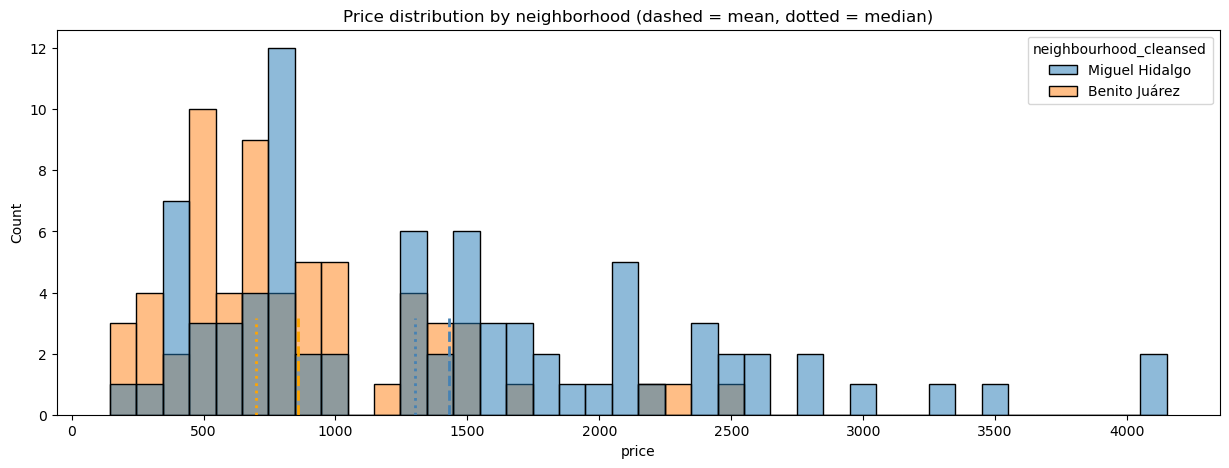

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
subset = price_df.loc[price_df["neighbourhood_cleansed"].isin(selected_neighborhoods)]

sns.histplot(data=subset, x="price", hue="neighbourhood_cleansed", bins=40, ax=ax)

for neighborhood, color in zip(selected_neighborhoods, ["steelblue", "orange"]):
    prices = price_df.loc[price_df["neighbourhood_cleansed"] == neighborhood, "price"]
    ax.axvline(prices.mean(), color=color, linestyle="dashed", linewidth=2, ymax=0.25)
    ax.axvline(prices.median(), color=color, linestyle="dotted", linewidth=2, ymax=0.25)

ax.set_title("Price distribution by neighborhood (dashed = mean, dotted = median)")
plt.show()

The gap between each mean and its median is the skew, and it is the reason the mean difference will carry a wide interval: a handful of expensive listings move the mean a long way in samples this size.

### Step 0. Define what difference would change the decision

Do this **before** looking at the test result, otherwise the threshold gets chosen to match whatever came out.

"Is there a difference?" and "is the difference big enough to act on?" are different questions, and only the second one has business value. A test against zero can return a decisive p-value for a difference far too small to matter — and, as we will see, an interval so wide that it is compatible with both outcomes at once.

The value below is illustrative. In class, ask the students to commit to a number first: *at what nightly price gap would you actually change which neighborhood you buy in?*

In [19]:
# Business threshold: the smallest difference in mean nightly price that would
# change the investment decision. This is a business input, not a statistic.
practical_threshold = 300.0   # monetary units per night

**Step 1.** Define null and alternative hypothesis.

Note these are statements about **population means** ($\mu$), not about the sample means we observed. We already know the sample means differ; that is not in question.

$$
H_0: \mu_1 = \mu_2
$$
$$
H_a: \mu_1 \neq \mu_2
$$

And, separately, the question the investor actually asked:

$$
H_0': \mu_1 - \mu_2 \leq \delta \qquad H_a': \mu_1 - \mu_2 > \delta \qquad (\delta = \text{practical threshold})
$$

**Step 2.** Define the significance level desired:

In [20]:
alpha = 0.01

**Step 3.** Choose the appropriate test.

We use **Welch's t-test**. Two things are worth being precise about, because both are commonly misstated:

- Welch does not *assume unequal variances*; it simply does not *require* equal ones. It keeps the two variances separate in the standard error, $\sqrt{s_1^2/n_1 + s_2^2/n_2}$, and spends the difference on fractional degrees of freedom (Welch–Satterthwaite). Using it by default costs almost no power when variances happen to be equal, and protects the error rate when they are not.
- The normality assumption is **not** about `price`. Advertised prices are strongly right-skewed and nobody expects otherwise. What needs to be approximately normal is the *sampling distribution of the difference in means*. With group sizes in the tens and a heavy right tail, the CLT is an approximation of unknown quality here — so we verify it below instead of running a normality pre-test on the raw variable.

(Why not a Shapiro–Wilk pre-test? It has no power to detect relevant departures at small $n$, rejects on trivial ones at large $n$, and conditioning the main test on its outcome distorts the error rate of the procedure as a whole.)

In [21]:
a = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[0], "price"]
b = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[1], "price"]

print(f"{selected_neighborhoods[0]}: n = {len(a)}, mean = {a.mean():.1f}, sd = {a.std():.1f}")
print(f"{selected_neighborhoods[1]}: n = {len(b)}, mean = {b.mean():.1f}, sd = {b.std():.1f}")

Miguel Hidalgo: n = 79, mean = 1429.2, sd = 900.7
Benito Juárez: n = 61, mean = 856.3, sd = 501.3


**Step 4.** Calculate the estimate, its interval, and the test statistic.

Reporting order is deliberate: the estimate and its interval first, the p-value last. The p-value is a summary of the interval's position relative to one particular value, not the result itself.

In [22]:
result = ttest_ind(a, b, equal_var=False)

# NOTE: the argument is `confidence_level`, not alpha. Passing alpha positionally
# silently produces a 1% interval that looks reassuringly narrow.
ci = result.confidence_interval(confidence_level=1 - alpha)

diff = a.mean() - b.mean()

print(f"Difference in means: {diff:>10.1f}")
print(f"CI{100 * (1 - alpha):.0f}%:              [{ci.low:.1f}, {ci.high:.1f}]   (width = {ci.high - ci.low:.1f})")
print(f"t-statistic:         {result.statistic:>10.4f}")
print(f"degrees of freedom:  {result.df:>10.1f}   (fractional -> Welch, not Student)")
print(f"p-value:             {result.pvalue:>10.4g}")

Difference in means:      572.9
CI99%:              [259.2, 886.6]   (width = 627.4)
t-statistic:             4.7764
degrees of freedom:       126.6   (fractional -> Welch, not Student)
p-value:              4.852e-06


**Read the interval before anything else.** Its width, relative to the estimate, is the headline. If the interval spans from "negligible" to "enormous", then the honest summary is that we have established the *sign* of the difference and very little about its *size* — regardless of how small the p-value is.

### Step 4b. Verify the normality assumption (instead of asserting it)

A bootstrap interval makes no normality assumption about the sampling distribution: it resamples the observed data directly. If it broadly agrees with Welch's interval, the t approximation is adequate for practical purposes. If it is shifted or noticeably wider, the CLT has not kicked in at this sample size and the t interval is overconfident.

This is generate-then-verify applied to a statistical assumption rather than to code.

In [23]:
def mean_diff(x, y, axis=-1):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


boot = bootstrap(
    (a.values, b.values),
    mean_diff,
    vectorized=True,
    paired=False,
    n_resamples=10_000,
    confidence_level=1 - alpha,
    method="BCa",
    random_state=RANDOM_STATE,
)

print(f"Welch   CI{100 * (1 - alpha):.0f}%: [{ci.low:.1f}, {ci.high:.1f}]")
print(f"Boot    CI{100 * (1 - alpha):.0f}%: [{boot.confidence_interval.low:.1f}, "
      f"{boot.confidence_interval.high:.1f}]")

Welch   CI99%: [259.2, 886.6]
Boot    CI99%: [266.7, 896.8]


### Step 4c. Verify the independence assumption

Both intervals above treat every listing as an independent observation. If some hosts contribute several listings, that is false, and both are too narrow.

The cluster bootstrap resamples **hosts**, not listings, keeping each host's listings together. The resulting interval is the honest one when listings cluster by host. The gap between the two widths is the price of the independence assumption — and unlike the normality issue, no amount of extra data would close it.

In [24]:
def cluster_bootstrap_diff(group_a, group_b, n_boot=5_000, seed=RANDOM_STATE):
    # Bootstrap the difference in means by resampling hosts, not listings.
    rng_local = np.random.default_rng(seed)
    clusters_a = [g["price"].values for _, g in group_a.groupby("host_id")]
    clusters_b = [g["price"].values for _, g in group_b.groupby("host_id")]

    stats_out = np.empty(n_boot)
    for i in range(n_boot):
        idx_a = rng_local.integers(0, len(clusters_a), len(clusters_a))
        idx_b = rng_local.integers(0, len(clusters_b), len(clusters_b))
        sample_a = np.concatenate([clusters_a[j] for j in idx_a])
        sample_b = np.concatenate([clusters_b[j] for j in idx_b])
        stats_out[i] = sample_a.mean() - sample_b.mean()
    return stats_out


group_a = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[0]]
group_b = price_df.loc[price_df["neighbourhood_cleansed"] == selected_neighborhoods[1]]

cluster_stats = cluster_bootstrap_diff(group_a, group_b)
lo, hi = np.percentile(cluster_stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])

print(f"Welch              CI: [{ci.low:.1f}, {ci.high:.1f}]   width = {ci.high - ci.low:.1f}")
print(f"Bootstrap (listings) CI: [{boot.confidence_interval.low:.1f}, "
      f"{boot.confidence_interval.high:.1f}]   width = "
      f"{boot.confidence_interval.high - boot.confidence_interval.low:.1f}")
print(f"Bootstrap (hosts)    CI: [{lo:.1f}, {hi:.1f}]   width = {hi - lo:.1f}")

Welch              CI: [259.2, 886.6]   width = 627.4
Bootstrap (listings) CI: [266.7, 896.8]   width = 630.1
Bootstrap (hosts)    CI: [271.4, 884.8]   width = 613.4


### Step 4d. Effect size

Hedges' *g* rescales the difference into standard deviations. Its only real job is **comparability** — pooling results measured on different scales, as a meta-analysis does. It adds no information here, where the units are already money the client understands, so treat it as secondary to the raw difference.

Two rules we follow, both of which the earlier version broke:

- **Always report it with an interval.** *g* inherits every bit of uncertainty that the raw difference has; printing a bare point estimate just hides it behind a tidier number.
- **No verbal labels.** Snapping *g* to "small / moderate / large" converts an uncertain estimate into a category and manufactures a sense of resolution that the data does not support. Cohen's 0.2 / 0.5 / 0.8 are conventions from psychology research, not decision criteria — and if the interval spans two of the labels, the labels were never the right output.

One caveat worth naming aloud: *g* uses a **pooled** standard deviation, which sits awkwardly with having chosen Welch precisely because the variances differ. With similar variances the distinction is cosmetic; with very different ones, consider Glass's delta instead.

In [25]:
def hedges_g(x, y):
    n1, n2 = len(x), len(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    sp = np.sqrt(((n1 - 1) * s1 ** 2 + (n2 - 1) * s2 ** 2) / (n1 + n2 - 2))
    d = (np.mean(x) - np.mean(y)) / sp
    df_pooled = n1 + n2 - 2
    return d * (1 - 3 / (4 * df_pooled - 1))          # bias-corrected (Hedges' g)


g_boot = bootstrap(
    (a.values, b.values),
    lambda x, y: hedges_g(x, y),
    vectorized=False,
    paired=False,
    n_resamples=5_000,
    confidence_level=1 - alpha,
    method="percentile",
    random_state=RANDOM_STATE,
)

print(f"Hedges' g: {hedges_g(a.values, b.values):.3f}  "
      f"CI{100 * (1 - alpha):.0f}% [{g_boot.confidence_interval.low:.3f}, "
      f"{g_boot.confidence_interval.high:.3f}]")
print("Cohen's conventional reference points (psychology research, not business criteria): 0.2 / 0.5 / 0.8")

Hedges' g: 0.756  CI99% [0.385, 1.164]
Cohen's conventional reference points (psychology research, not business criteria): 0.2 / 0.5 / 0.8


**Step 5.** Interpret and decide.

Two decisions, not one. The first is statistical, the second is the one the client is paying for.

In [26]:
# Decision 1: is the difference distinguishable from zero?
if result.pvalue <= alpha:
    print(f"REJECT H0: the difference in listing price between {selected_neighborhoods[0]} "
          f"and {selected_neighborhoods[1]} is statistically distinguishable from zero.")
else:
    print(f"FAIL TO REJECT H0: the difference between {selected_neighborhoods[0]} and "
          f"{selected_neighborhoods[1]} is not distinguishable from zero at alpha = {alpha}.")

REJECT H0: the difference in listing price between Miguel Hidalgo and Benito Juárez is statistically distinguishable from zero.


In [27]:
def welch_against(x, y, delta0=0.0, alternative="two-sided"):
    # Welch's t-test against an arbitrary threshold, not just zero.
    n1, n2 = len(x), len(y)
    v1, v2 = np.var(x, ddof=1) / n1, np.var(y, ddof=1) / n2
    se = np.sqrt(v1 + v2)
    df = (v1 + v2) ** 2 / (v1 ** 2 / (n1 - 1) + v2 ** 2 / (n2 - 1))
    t = (np.mean(x) - np.mean(y) - delta0) / se

    if alternative == "two-sided":
        p = 2 * stats.t.sf(abs(t), df)
    elif alternative == "greater":
        p = stats.t.sf(t, df)
    else:
        p = stats.t.cdf(t, df)
    return t, df, p


# Decision 2: is the difference past the threshold that would change the decision?
t_thr, df_thr, p_thr = welch_against(a.values, b.values,
                                     delta0=practical_threshold, alternative="greater")

print(f"H0': difference <= {practical_threshold:.0f}")
print(f"t = {t_thr:.3f}, df = {df_thr:.1f}, p = {p_thr:.4g}")
print()
if p_thr <= alpha:
    print(f"The data support a difference LARGER than {practical_threshold:.0f} per night.")
else:
    print(f"The data do NOT establish a difference larger than {practical_threshold:.0f} per night,")
    print("even if the difference is distinguishable from zero. Same data, different question.")

H0': difference <= 300
t = 2.275, df = 126.6, p = 0.01228

The data do NOT establish a difference larger than 300 per night,
even if the difference is distinguishable from zero. Same data, different question.


### Sensitivity check: does the outlier trim drive the conclusion?

If removing the top tail changes the answer, then the answer is a statement about our trimming rule rather than about the neighborhoods, and the rule has to be justified on its own terms.

In [28]:
a_raw = price_untrimmed_df.loc[
    price_untrimmed_df["neighbourhood_cleansed"] == selected_neighborhoods[0], "price"]
b_raw = price_untrimmed_df.loc[
    price_untrimmed_df["neighbourhood_cleansed"] == selected_neighborhoods[1], "price"]

res_raw = ttest_ind(a_raw, b_raw, equal_var=False)
ci_raw = res_raw.confidence_interval(confidence_level=1 - alpha)

print(f"{'':<12}{'n1':>5}{'n2':>5}{'diff':>10}{'CI low':>11}{'CI high':>11}{'p':>12}")
print(f"{'trimmed':<12}{len(a):>5}{len(b):>5}{diff:>10.1f}{ci.low:>11.1f}{ci.high:>11.1f}"
      f"{result.pvalue:>12.4g}")
print(f"{'untrimmed':<12}{len(a_raw):>5}{len(b_raw):>5}{a_raw.mean() - b_raw.mean():>10.1f}"
      f"{ci_raw.low:>11.1f}{ci_raw.high:>11.1f}{res_raw.pvalue:>12.4g}")

               n1   n2      diff     CI low    CI high           p
trimmed        79   61     572.9      259.2      886.6   4.852e-06
untrimmed      81   62     855.1       54.7     1655.4    0.006043


**Potential implication for an investor:**

Listing prices in Miguel Hidalgo are higher than in Benito Juárez, and the direction of that gap is reasonably well established. Its **size is not**: the confidence interval spans from a difference small enough to be commercially irrelevant to one several times larger. In practice we have learned the sign and little else.

Three limits that the test cannot address, and that belong in any deliverable built on it:

- **Composition, not just location.** This is an unadjusted comparison. If Miguel Hidalgo listings tend to be larger — more bedrooms, higher `accommodates` — part of the gap is property size rather than neighborhood premium. A comparison holding capacity fixed would answer a different and more useful question.
- **Advertised price is not revenue.** The dataset records what hosts ask, not what guests paid, and says nothing about occupancy, cleaning fees or minimum-stay rules. "More expensive" and "more profitable" are not the same claim.
- **Selection for significance inflates magnitude.** When power is limited, a result only clears the significance filter if noise happened to run in its favour — so the observed difference is, on average, larger than the true one. This is a reason to trust the lower end of the interval more than the point estimate.

The defensible recommendation is therefore conditional: Miguel Hidalgo commands higher advertised prices, but this sample cannot establish that the gap exceeds the threshold that would justify reallocating capital. Deciding on that basis needs either a larger sample or an adjusted model — and a larger sample would only help if listings from the same host are handled properly.

## Business question 2

To select the best room type to invest in, are there room types that are more prevalent in certain neighborhoods?

Here we use **all** room types (with rare ones collapsed into `Other`), not the investor-relevant subset. Question 1 asks about a market an investor would enter; question 2 asks how the market is composed, and dropping categories in advance would answer a narrower question than the one posed.

In [29]:
neighborhood_frec_cumsum = (listings_df["neighbourhood_cleansed"]
                            .value_counts(dropna=False, normalize=True)
                            .cumsum())
neighborhood_frec_cumsum

neighbourhood_cleansed
Cuauhtémoc                0.476378
Miguel Hidalgo            0.637795
Benito Juárez             0.761811
Coyoacán                  0.820866
Álvaro Obregón            0.858268
Tlalpan                   0.893701
Venustiano Carranza       0.925197
Gustavo A. Madero         0.944882
Cuajimalpa de Morelos     0.962598
Iztacalco                 0.972441
Iztapalapa                0.980315
Xochimilco                0.988189
Azcapotzalco              0.994094
La Magdalena Contreras    0.998031
Tláhuac                   1.000000
Name: proportion, dtype: float64

In [30]:
# Pareto filter at 85%: keep neighborhoods up to AND INCLUDING the one that crosses
# the threshold. A strict `< 0.85` silently drops the crossing neighborhood.
PARETO = 0.85
mask = neighborhood_frec_cumsum.shift(fill_value=0) < PARETO
most_representative_neighborhoods = neighborhood_frec_cumsum.loc[mask].index.tolist()
most_representative_neighborhoods

['Cuauhtémoc', 'Miguel Hidalgo', 'Benito Juárez', 'Coyoacán', 'Álvaro Obregón']

In [31]:
q2_df = listings_df.loc[
    listings_df["neighbourhood_cleansed"].isin(most_representative_neighborhoods)]

contingency_table = pd.crosstab(q2_df["neighbourhood_cleansed"], q2_df["room_type_grouped"])
contingency_table

room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,44,1,18
Coyoacán,12,2,16
Cuauhtémoc,168,6,68
Miguel Hidalgo,62,1,19
Álvaro Obregón,12,1,6


**Step 1.** Define null and alternative hypothesis:

$$
H_0: \text{The variables are independent}
$$
$$
H_a: \text{The variables are not independent}
$$

("Not dependent" and "independent" are the same thing here, but the second is the statement the test actually evaluates — worth being exact about in a course on inference.)

**Step 2.** Define the significance level desired:

In [32]:
alpha = 0.01

**Step 3.** Check the assumption before running the test.

The chi-square statistic relies on a large-sample approximation. The usual rule of thumb is that **every expected cell count should be at least 5** — and with a 2% subsample spread across a dozen neighborhoods, that is a real risk rather than a formality. The original notebook captured `expected` and never looked at it.

If the rule fails, the options are to collapse sparse categories further or to use an exact test (`scipy.stats.fisher_exact` for 2×2, or a permutation version of the chi-square for larger tables).

In [33]:
chi2, pvalue, dof, expected = chi2_contingency(contingency_table, correction=False)

expected_df = pd.DataFrame(expected,
                           index=contingency_table.index,
                           columns=contingency_table.columns)

print(f"Minimum expected count: {expected.min():.2f}")
print(f"Cells with expected < 5: {(expected < 5).sum()} out of {expected.size}")
if expected.min() < 5:
    print("WARNING: the chi-square approximation is unreliable here. "
          "Collapse categories or use an exact / permutation test.")
expected_df.round(1)

Minimum expected count: 0.48
Cells with expected < 5: 4 out of 15


room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,43.1,1.6,18.4
Coyoacán,20.5,0.8,8.7
Cuauhtémoc,165.4,6.1,70.5
Miguel Hidalgo,56.0,2.1,23.9
Álvaro Obregón,13.0,0.5,5.5


**Step 4.** Calculate the statistic, p-value, and effect size.

In [34]:
n = contingency_table.values.sum()
r, k = contingency_table.shape

phi2 = chi2 / n
phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
r_corr = r - ((r - 1) ** 2) / (n - 1)
k_corr = k - ((k - 1) ** 2) / (n - 1)

cramers_v = np.sqrt(phi2_corr / max(1e-12, min(r_corr - 1, k_corr - 1)))  # bias-corrected

In [35]:
print(f"chi-square: {chi2:.4f}")
print(f"dof:        {dof}")
print(f"p-value:    {pvalue:.4g}")
print(f"Cramér's V: {cramers_v:.3f}")

# Cohen's 0.1 / 0.3 / 0.5 reference points are defined for dof = 1 tables.
# For larger tables they must be scaled by sqrt(min(r-1, k-1)).
df_star = min(r - 1, k - 1)
scaled = ", ".join(f"{x / np.sqrt(df_star):.3f}" for x in (0.1, 0.3, 0.5))
print(f"\nReference points for a table with min(r-1, k-1) = {df_star}: {scaled}")
print("These are conventions, not thresholds. Report V; do not convert it to a label.")

chi-square: 14.8431
dof:        8
p-value:    0.06227
Cramér's V: 0.089

Reference points for a table with min(r-1, k-1) = 2: 0.071, 0.212, 0.354
These are conventions, not thresholds. Report V; do not convert it to a label.


**Step 5.** Interpret and decide.

A chi-square test says *whether* the variables are associated. It does not say **where** the association is or in which direction — for that we need the standardized residuals, which show which cells depart from what independence would predict, and by how much. Values beyond roughly ±2 mark the cells driving the result.

In [36]:
if pvalue <= alpha:
    print("REJECT H0: neighborhood and room type are not independent in this sample.")
else:
    print(f"FAIL TO REJECT H0: no association detectable at alpha = {alpha}.")

FAIL TO REJECT H0: no association detectable at alpha = 0.01.


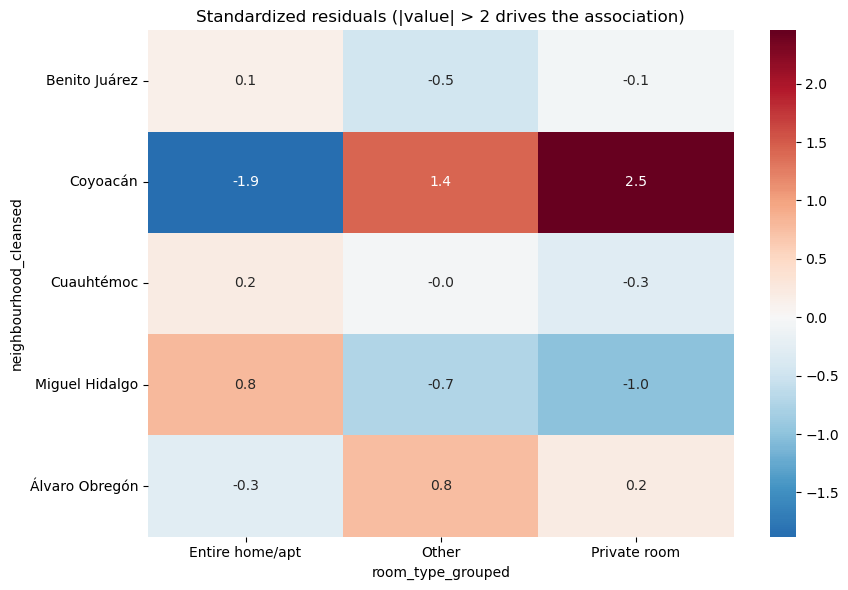

room_type_grouped,Entire home/apt,Other,Private room
neighbourhood_cleansed,,,
Benito Juárez,0.14,-0.47,-0.08
Coyoacán,-1.88,1.43,2.46
Cuauhtémoc,0.20,-0.04,-0.30
Miguel Hidalgo,0.80,-0.74,-1.00
Álvaro Obregón,-0.27,0.75,0.20


In [37]:
# Standardized (Pearson) residuals: (observed - expected) / sqrt(expected)
residuals = (contingency_table - expected_df) / np.sqrt(expected_df)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(residuals, annot=True, fmt=".1f", center=0, cmap="RdBu_r", ax=ax)
ax.set_title("Standardized residuals (|value| > 2 drives the association)")
plt.tight_layout()
plt.show()

residuals.round(2)

**Potential implication for an investor:**

The residual map identifies which neighborhoods over- or under-represent each room type relative to an independent market. Read the cells beyond ±2 and name them explicitly; the chi-square statistic alone supports no directional claim.

Whether gentrification or residential character explains the pattern is a **causal hypothesis about a cross-sectional association** — a reasonable thing to raise as a question for further study, and not something these data can settle. Prevalence differences are equally consistent with zoning rules, building stock age, tourism corridors, and platform-level enforcement of short-term-rental regulation.

## Limitations of this analysis

Collected in one place, so they travel with any conclusion drawn from the notebook.

1. **Multiplicity.** Two tests were run at $\alpha = 0.01$, on top of a data-informed choice of the Pareto cut and of which neighborhoods to compare. No correction was applied. That is defensible in a tutorial, but the count has to be declared: error rates are properties of the whole procedure, not of the last test you happened to run.
2. **Independence.** Listings cluster by host. The cluster bootstrap quantifies the cost; the conventional interval understates it. Extra data narrows the interval without fixing this.
3. **Estimand.** All results refer to *advertised nightly price*, in a 2% sample, excluding hotel and shared rooms, excluding extreme prices, on the scrape date. Each of those clauses narrows what may legitimately be claimed.
4. **No adjustment for composition.** Neighborhood differences conflate location with property mix.
5. **Magnitude is bounded, not known.** Intervals say how little we know; they do not say how confident we are. Their width is the finding, and a threshold fixed in advance is what turns that width into a decision.

### Exercises

1. Re-run question 1 with `RANDOM_STATE` set to a different value. How much do the difference, the interval and the p-value move? What does that tell you about a single point estimate?
2. Set `practical_threshold` to a value inside the confidence interval and to one outside it. Explain why the same data support opposite recommendations.
3. Adjust the price comparison for `accommodates` (compare within capacity bands, or fit `price ~ neighborhood + accommodates`). Does the neighborhood gap survive?
4. Compare the three intervals from Step 4b and 4c. Which assumption costs more here — normality or independence?